# EDA: E-Commerce Customer Behavior (v2)
This notebook performs exploratory data analysis aligned with the project goals in the README files:
- understand transaction and customer behavior
- prepare CLV and segmentation-ready insights
- identify patterns useful for downstream modeling

Dataset used: `ecommerce_customer_behavior_dataset_v2.csv`

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

data_path = Path("ecommerce_customer_behavior_dataset_v2.csv")
df = pd.read_csv(data_path, parse_dates=["Date"])

print(f"Loaded {len(df):,} transactions from {data_path}")
df.head()

Loaded 17,049 transactions from ecommerce_customer_behavior_dataset_v2.csv


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,"1,664.10",Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [7]:
# Basic structure overview
n_transactions = len(df)
n_customers = df["Customer_ID"].nunique()
date_min, date_max = df["Date"].min(), df["Date"].max()

print(f"Transactions: {n_transactions:,}")
print(f"Unique customers: {n_customers:,}")
print(f"Date range: {date_min.date()} to {date_max.date()}")
print(f"Average orders per customer: {n_transactions / n_customers:.2f}")

display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all").T.head(20))

Transactions: 17,049
Unique customers: 5,000
Date range: 2023-01-01 to 2024-03-25
Average orders per customer: 3.41


,dtype
Order_ID,object
Customer_ID,object
Date,datetime64[ns]
Age,int64
Gender,object
City,object
Product_Category,object
Unit_Price,float64
Quantity,int64
Discount_Amount,float64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,17049,17049,ORD_000001-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,17049,5000,CUST_02860,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,17049,NaN,NaN,NaN,2023-08-15 01:33:09.723737344,2023-01-01 00:00:00,2023-04-26 00:00:00,2023-08-16 00:00:00,2023-12-06 00:00:00,2024-03-25 00:00:00,NaN
Age,"17,049.00",NaN,NaN,NaN,34.95,18.00,26.00,35.00,42.00,75.00,11.05
Gender,17049,3,Female,8613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,17049,10,Istanbul,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,17049,8,Sports,2248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit_Price,"17,049.00",NaN,NaN,NaN,447.90,5.05,73.26,174.68,494.57,"7,900.01",722.32
Quantity,"17,049.00",NaN,NaN,NaN,3.01,1.00,2.00,3.00,4.00,5.00,1.42
Discount_Amount,"17,049.00",NaN,NaN,NaN,69.79,0.00,0.00,0.00,32.71,"6,538.29",240.70


In [8]:
# Data quality checks
missing_counts = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()
order_id_unique = df["Order_ID"].is_unique

print("Top missing-value counts:")
display(missing_counts[missing_counts > 0])
print(f"Duplicate rows: {duplicate_rows}")
print(f"Order_ID unique: {order_id_unique}")

# Sanity check for total amount consistency
expected_total = (df["Unit_Price"] * df["Quantity"] - df["Discount_Amount"]).round(2)
total_mismatch = (expected_total != df["Total_Amount"].round(2)).sum()
print(f"Rows with Total_Amount mismatch: {total_mismatch}")

Top missing-value counts:


Series([], dtype: int64)

Duplicate rows: 0
Order_ID unique: True
Rows with Total_Amount mismatch: 0


In [9]:
# Create EDA-friendly derived metrics
df = df.copy()
df["Gross_Amount"] = df["Unit_Price"] * df["Quantity"]
df["Discount_Rate"] = np.where(
    df["Gross_Amount"] > 0,
    df["Discount_Amount"] / df["Gross_Amount"],
    0.0,
 )

numeric_cols = [
    "Unit_Price", "Quantity", "Discount_Amount", "Gross_Amount",
    "Total_Amount", "Discount_Rate", "Session_Duration_Minutes",
    "Pages_Viewed", "Delivery_Time_Days", "Customer_Rating",
 ]

display(df[numeric_cols].describe().T)
print(f"Max discount rate: {df['Discount_Rate'].max():.2%}")
print(f"Median total amount: {df['Total_Amount'].median():,.2f}")

,count,mean,std,min,25%,50%,75%,max
Unit_Price,"17,049.00",447.90,722.32,5.05,73.26,174.68,494.57,"7,900.01"
Quantity,"17,049.00",3.01,1.42,1.00,2.00,3.00,4.00,5.00
Discount_Amount,"17,049.00",69.79,240.70,0.00,0.00,0.00,32.71,"6,538.29"
Gross_Amount,"17,049.00","1,347.23","2,477.53",6.30,182.56,479.91,"1,333.62","37,852.05"
Total_Amount,"17,049.00","1,277.44","2,358.44",6.21,172.97,455.85,"1,267.75","37,852.05"
Discount_Rate,"17,049.00",0.05,0.07,0.00,0.00,0.00,0.11,0.22
Session_Duration_Minutes,"17,049.00",14.54,2.93,4.00,13.00,15.00,17.00,26.00
Pages_Viewed,"17,049.00",9.00,2.26,1.00,7.00,9.00,11.00,18.00
Delivery_Time_Days,"17,049.00",6.50,3.49,1.00,4.00,6.00,8.00,25.00
Customer_Rating,"17,049.00",3.90,1.13,1.00,3.00,4.00,5.00,5.00


Max discount rate: 22.00%
Median total amount: 455.85


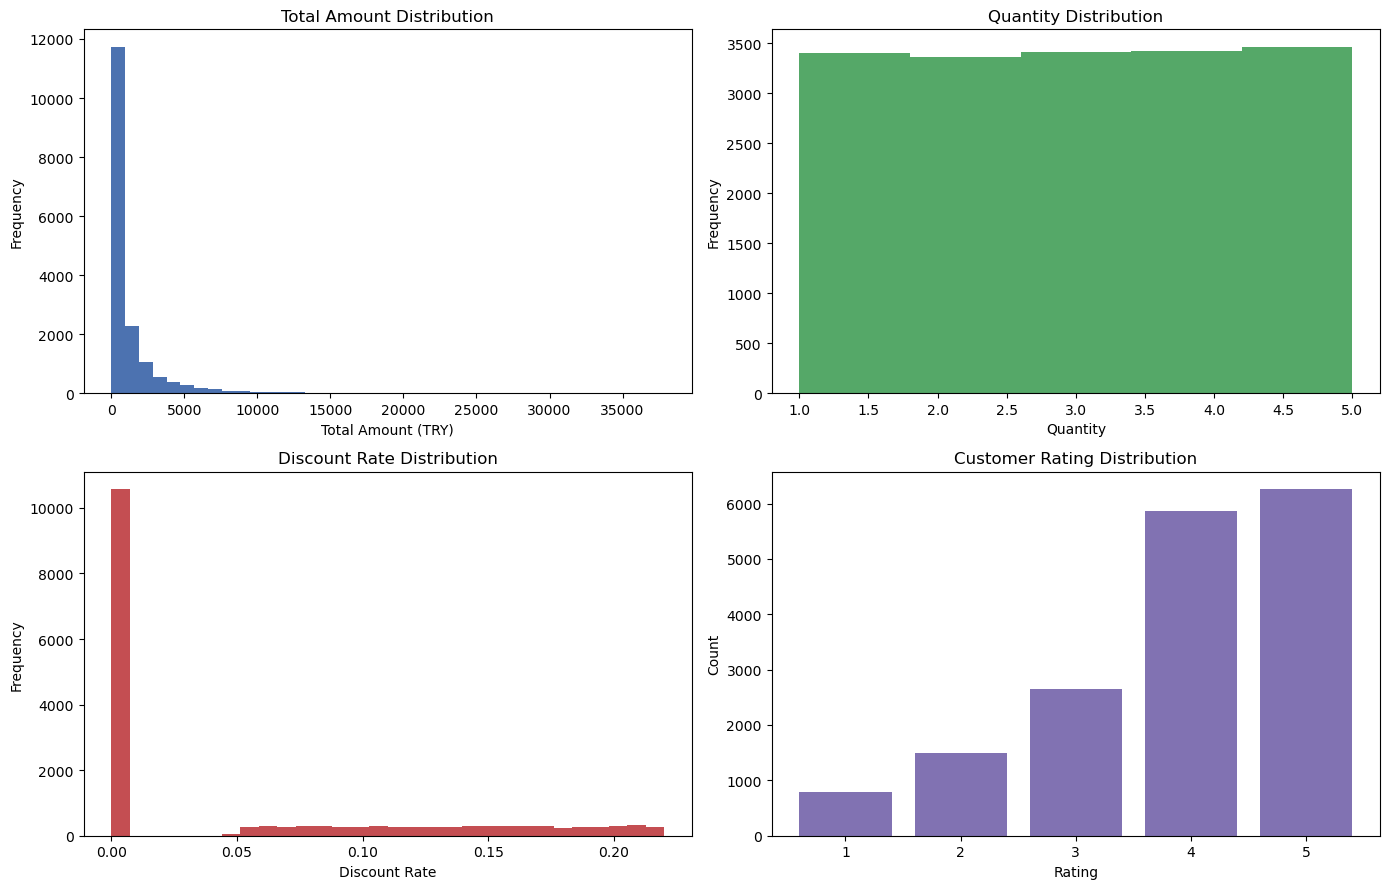

In [10]:
# Univariate distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

df["Total_Amount"].plot(kind="hist", bins=40, ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Total Amount Distribution")
axes[0, 0].set_xlabel("Total Amount (TRY)")

df["Quantity"].plot(kind="hist", bins=5, ax=axes[0, 1], color="#55a868")
axes[0, 1].set_title("Quantity Distribution")
axes[0, 1].set_xlabel("Quantity")

df["Discount_Rate"].plot(kind="hist", bins=30, ax=axes[1, 0], color="#c44e52")
axes[1, 0].set_title("Discount Rate Distribution")
axes[1, 0].set_xlabel("Discount Rate")

rating_counts = df["Customer_Rating"].value_counts().sort_index()
axes[1, 1].bar(rating_counts.index.astype(str), rating_counts.values, color="#8172b2")
axes[1, 1].set_title("Customer Rating Distribution")
axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

,orders,revenue,avg_rating,avg_discount_rate
Product_Category,,,,
Electronics,2074,"10,481,897.65",3.90,0.05
Home & Garden,2060,"4,023,903.94",3.93,0.05
Sports,2248,"3,205,086.99",3.92,0.05
Fashion,2056,"1,577,035.70",3.89,0.05
Toys,2090,"1,014,237.53",3.90,0.05
Beauty,2212,"694,437.02",3.92,0.05
Food,2103,"422,054.65",3.86,0.05
Books,2206,"360,399.11",3.88,0.05


,orders,revenue,unique_customers
City,,,
Istanbul,4402,"5,646,595.78",1284
Ankara,2422,"3,052,443.10",735
Izmir,2072,"2,651,743.92",600
Bursa,1721,"2,317,028.10",496
Antalya,1246,"1,661,594.15",374
Gaziantep,1183,"1,573,422.25",349
Adana,1326,"1,512,320.19",378
Konya,1120,"1,363,152.80",317
Kayseri,851,"1,091,658.53",257


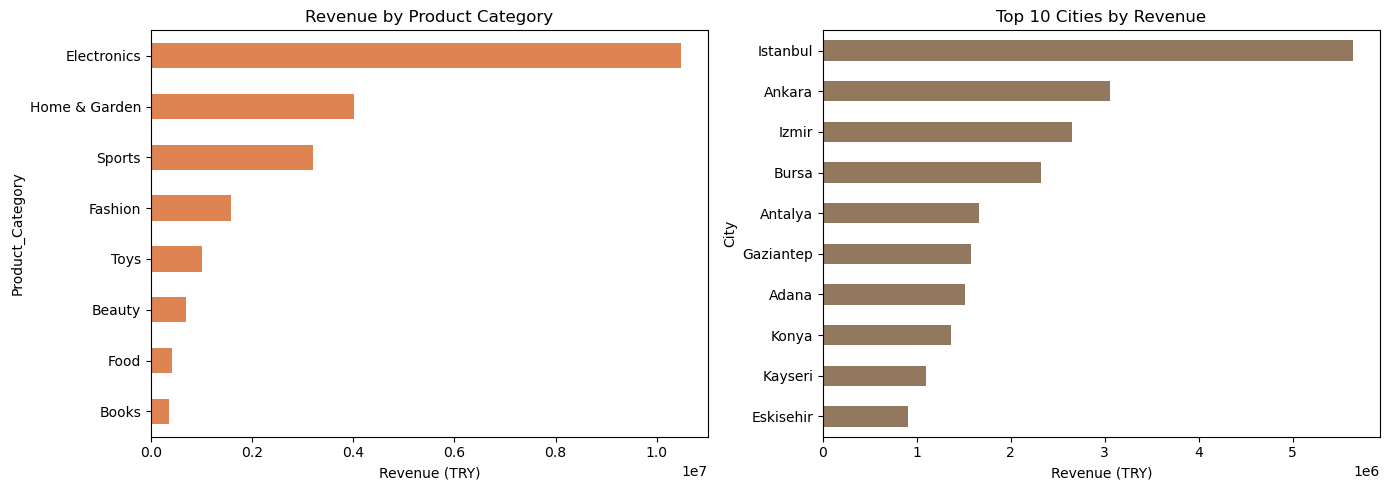

In [11]:
# Category and city performance
category_summary = (
    df.groupby("Product_Category")
    .agg(
        orders=("Order_ID", "count"),
        revenue=("Total_Amount", "sum"),
        avg_rating=("Customer_Rating", "mean"),
        avg_discount_rate=("Discount_Rate", "mean"),
    )
    .sort_values("revenue", ascending=False)
 )

city_summary = (
    df.groupby("City")
    .agg(
        orders=("Order_ID", "count"),
        revenue=("Total_Amount", "sum"),
        unique_customers=("Customer_ID", "nunique"),
    )
    .sort_values("revenue", ascending=False)
 )

display(category_summary)
display(city_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_summary["revenue"].sort_values().plot(kind="barh", ax=axes[0], color="#dd8452")
axes[0].set_title("Revenue by Product Category")
axes[0].set_xlabel("Revenue (TRY)")

city_summary["revenue"].head(10).sort_values().plot(kind="barh", ax=axes[1], color="#937860")
axes[1].set_title("Top 10 Cities by Revenue")
axes[1].set_xlabel("Revenue (TRY)")

plt.tight_layout()
plt.show()

,Month,orders,revenue,unique_customers
10,2023-11-01,1151,"1,446,439.79",1021
11,2023-12-01,1215,"1,586,213.77",1073
12,2024-01-01,1211,"1,490,824.78",1056
13,2024-02-01,1053,"1,329,884.01",925
14,2024-03-01,975,"1,272,101.99",884


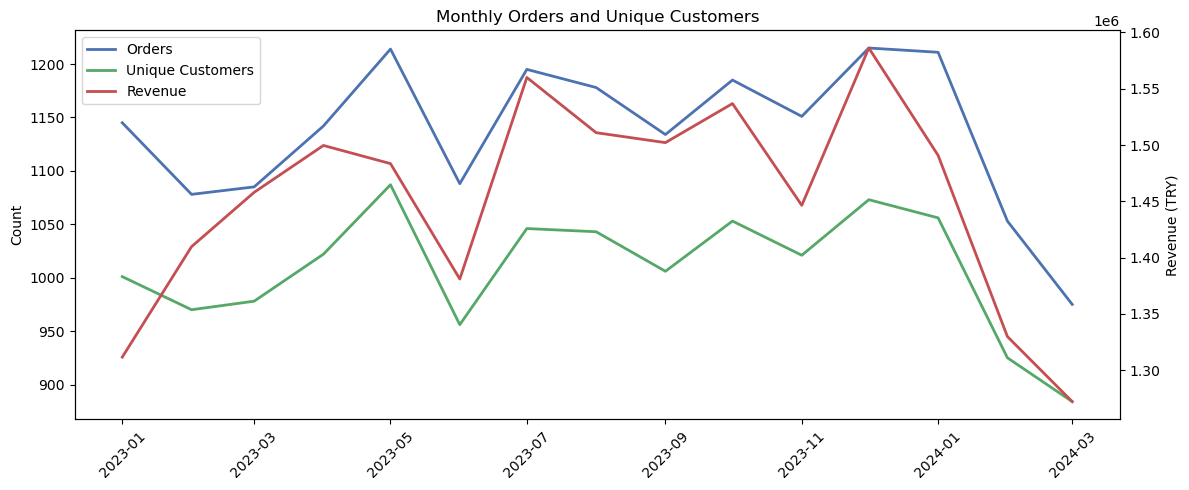

In [12]:
# Time trend analysis (monthly)
monthly = (
    df.assign(Month=df["Date"].dt.to_period("M").dt.to_timestamp())
    .groupby("Month")
    .agg(
        orders=("Order_ID", "count"),
        revenue=("Total_Amount", "sum"),
        unique_customers=("Customer_ID", "nunique"),
    )
    .reset_index()
 )

display(monthly.tail())

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["Month"], monthly["orders"], label="Orders", color="#4c72b0", linewidth=2)
ax1.plot(monthly["Month"], monthly["unique_customers"], label="Unique Customers", color="#55a868", linewidth=2)
ax1.set_ylabel("Count")
ax1.set_title("Monthly Orders and Unique Customers")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["Month"], monthly["revenue"], label="Revenue", color="#c44e52", linewidth=2)
ax2.set_ylabel("Revenue (TRY)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

,orders,avg_order_value,avg_discount_rate,avg_session_minutes,avg_pages_viewed,avg_rating
Is_Returning_Customer,,,,,,
False,2010,"1,287.73",0.05,14.48,8.93,3.88
True,15039,"1,276.06",0.05,14.54,9.01,3.90


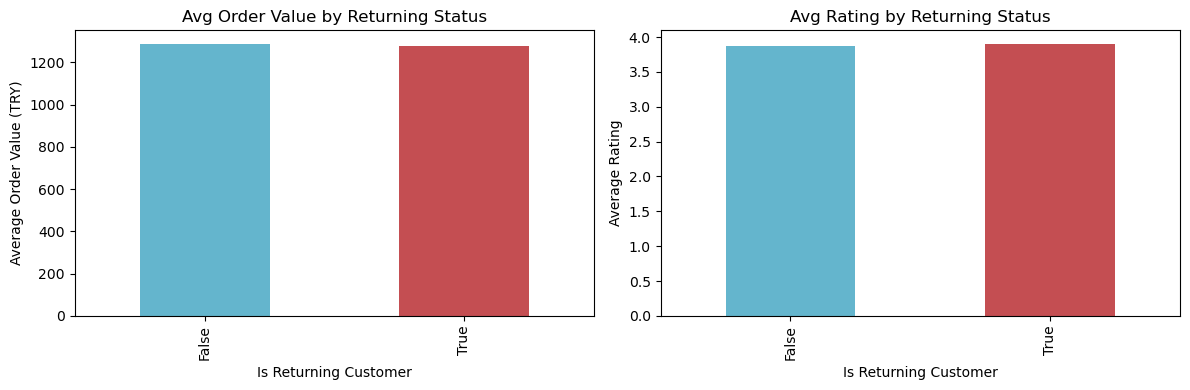

In [13]:
# Returning vs non-returning behavior
returning_summary = (
    df.groupby("Is_Returning_Customer")
    .agg(
        orders=("Order_ID", "count"),
        avg_order_value=("Total_Amount", "mean"),
        avg_discount_rate=("Discount_Rate", "mean"),
        avg_session_minutes=("Session_Duration_Minutes", "mean"),
        avg_pages_viewed=("Pages_Viewed", "mean"),
        avg_rating=("Customer_Rating", "mean"),
    )
 )

display(returning_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
returning_summary["avg_order_value"].plot(kind="bar", ax=axes[0], color=["#64b5cd", "#c44e52"])
axes[0].set_title("Avg Order Value by Returning Status")
axes[0].set_xlabel("Is Returning Customer")
axes[0].set_ylabel("Average Order Value (TRY)")

returning_summary["avg_rating"].plot(kind="bar", ax=axes[1], color=["#64b5cd", "#c44e52"])
axes[1].set_title("Avg Rating by Returning Status")
axes[1].set_xlabel("Is Returning Customer")
axes[1].set_ylabel("Average Rating")

plt.tight_layout()
plt.show()

,first_purchase,last_purchase,frequency,monetary_total,avg_order_value,avg_discount_rate,category_diversity,avg_rating,recency_days,tenure_days,clv_proxy,segment
Customer_ID,,,,,,,,,,,,
CUST_00001,2023-05-29,2023-12-05,3,"2,199.63",733.21,0.07,3,3.33,112,302,"2,199.63",Medium Value
CUST_00002,2023-05-11,2023-06-16,2,809.90,404.95,0.10,2,4.00,284,320,809.90,Low Value
CUST_00003,2023-02-27,2024-01-03,2,"3,030.81","1,515.40",0.00,2,3.50,83,393,"3,030.81",Medium Value
CUST_00004,2024-02-13,2024-02-13,1,383.22,383.22,0.20,1,5.00,42,42,383.22,Low Value
CUST_00005,2023-03-16,2023-06-21,3,"2,422.73",807.58,0.00,3,3.67,279,376,"2,422.73",Medium Value


,customers,avg_clv_proxy,avg_frequency,avg_recency_days,avg_category_diversity
segment,,,,,
High Value,1650,"9,930.66",5.04,89.67,3.75
Medium Value,1700,"2,611.36",3.29,118.83,2.73
Low Value,1650,578.28,1.90,168.85,1.72


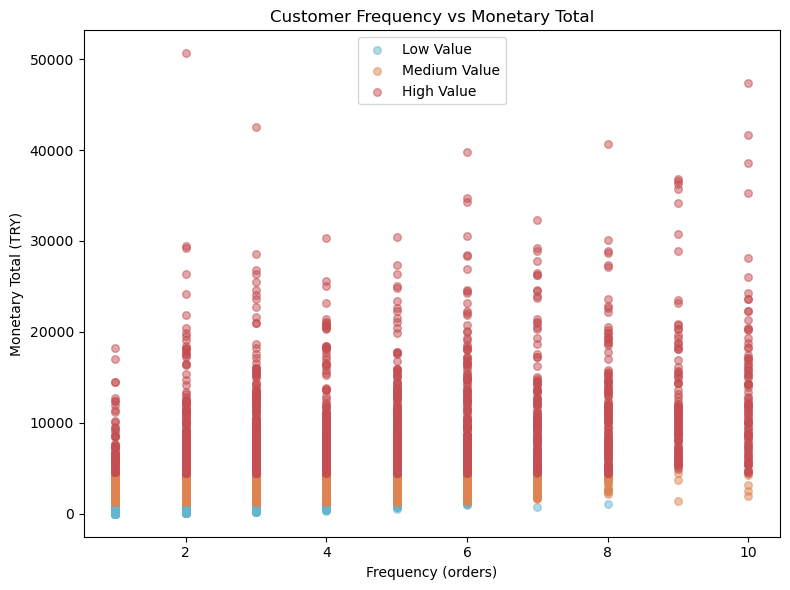

In [14]:
# Customer-level features for CLV/RFM-style analysis
snapshot_date = df["Date"].max() + pd.Timedelta(days=1)

customer_level = (
    df.groupby("Customer_ID")
    .agg(
        first_purchase=("Date", "min"),
        last_purchase=("Date", "max"),
        frequency=("Order_ID", "count"),
        monetary_total=("Total_Amount", "sum"),
        avg_order_value=("Total_Amount", "mean"),
        avg_discount_rate=("Discount_Rate", "mean"),
        category_diversity=("Product_Category", "nunique"),
        avg_rating=("Customer_Rating", "mean"),
    )
 )

customer_level["recency_days"] = (snapshot_date - customer_level["last_purchase"]).dt.days
customer_level["tenure_days"] = (snapshot_date - customer_level["first_purchase"]).dt.days
customer_level["clv_proxy"] = customer_level["monetary_total"]

q1, q2 = customer_level["clv_proxy"].quantile([0.33, 0.67])
customer_level["segment"] = np.select(
    [
        customer_level["clv_proxy"] <= q1,
        customer_level["clv_proxy"] <= q2,
    ],
    ["Low Value", "Medium Value"],
    default="High Value",
 )

segment_summary = (
    customer_level.groupby("segment")
    .agg(
        customers=("clv_proxy", "size"),
        avg_clv_proxy=("clv_proxy", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_category_diversity=("category_diversity", "mean"),
    )
    .sort_values("avg_clv_proxy", ascending=False)
 )

display(customer_level.head())
display(segment_summary)

fig, ax = plt.subplots(figsize=(8, 6))
segment_order = ["Low Value", "Medium Value", "High Value"]
colors = {"Low Value": "#64b5cd", "Medium Value": "#dd8452", "High Value": "#c44e52"}

for seg in segment_order:
    seg_data = customer_level[customer_level["segment"] == seg]
    ax.scatter(
        seg_data["frequency"],
        seg_data["monetary_total"],
        alpha=0.5,
        s=30,
        c=colors[seg],
        label=seg,
    )

ax.set_title("Customer Frequency vs Monetary Total")
ax.set_xlabel("Frequency (orders)")
ax.set_ylabel("Monetary Total (TRY)")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Auto-generated EDA takeaways
top_category = category_summary["revenue"].idxmax()
top_city = city_summary["revenue"].idxmax()
segment_counts = customer_level["segment"].value_counts()
return_rate = (df["Is_Returning_Customer"].mean() * 100)

print("Key findings from this EDA:")
print(f"1) Total transactions: {len(df):,} | unique customers: {df['Customer_ID'].nunique():,}")
print(f"2) Top revenue category: {top_category}")
print(f"3) Top revenue city: {top_city}")
print(f"4) Returning customer transaction share: {return_rate:.1f}%")
print(f"5) Segment distribution (customer-level):\n{segment_counts.to_string()}")

Key findings from this EDA:
1) Total transactions: 17,049 | unique customers: 5,000
2) Top revenue category: Electronics
3) Top revenue city: Istanbul
4) Returning customer transaction share: 88.2%
5) Segment distribution (customer-level):
segment
Medium Value    1700
Low Value       1650
High Value      1650
